In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [ ]:
data = pd.read_csv("DM_Week6_Student_Regression.csv")

print("Ukuran dataset (baris, kolom):", data.shape)
print("Jumlah nilai kosong          :", int(data.isna().sum().sum()))
data.head()

Ukuran dataset (baris, kolom): (179, 6)
Jumlah nilai kosong          : 0


,jam_belajar,kehadiran,nilai_tugas,nilai_kuis,aktivitas_forum,nilai_akhir
0,7.9,84.9,65.1,81.4,4,73.8
1,17.2,91.4,74.6,49.5,3,85.1
2,13.7,85.4,57.3,57.4,1,74.9
3,11.6,78.7,78.3,71.4,7,78.6
4,4.5,65.6,83.8,87.6,2,62.4


In [ ]:
TARGET = "nilai_akhir"
fitur = data.drop(columns=TARGET)
target = data[TARGET]

fitur_latih, fitur_uji, target_latih, target_uji = train_test_split(
    fitur, target, test_size=0.2, random_state=42
)

print(f"Data latih : {fitur_latih.shape[0]} baris")
print(f"Data uji   : {fitur_uji.shape[0]} baris")

Data latih : 143 baris
Data uji   : 36 baris


In [ ]:
kolom_tunggal = ["kehadiran"]

reg_sederhana = LinearRegression().fit(fitur_latih[kolom_tunggal], target_latih)
prediksi_sederhana = reg_sederhana.predict(fitur_uji[kolom_tunggal])

beta0 = reg_sederhana.intercept_
beta1 = reg_sederhana.coef_[0]

print("=== PARAMETER REGRESI LINEAR SEDERHANA ===")
print(f"Intersep (beta_0) : {beta0:.4f}")
print(f"Slope (beta_1)    : {beta1:.4f}")
print(f"Persamaan         : y_hat = {beta0:.2f} + {beta1:.2f} * kehadiran")

=== PARAMETER REGRESI LINEAR SEDERHANA ===
Intersep (beta_0) : 45.0715
Slope (beta_1)    : 0.3869
Persamaan         : y_hat = 45.07 + 0.39 * kehadiran


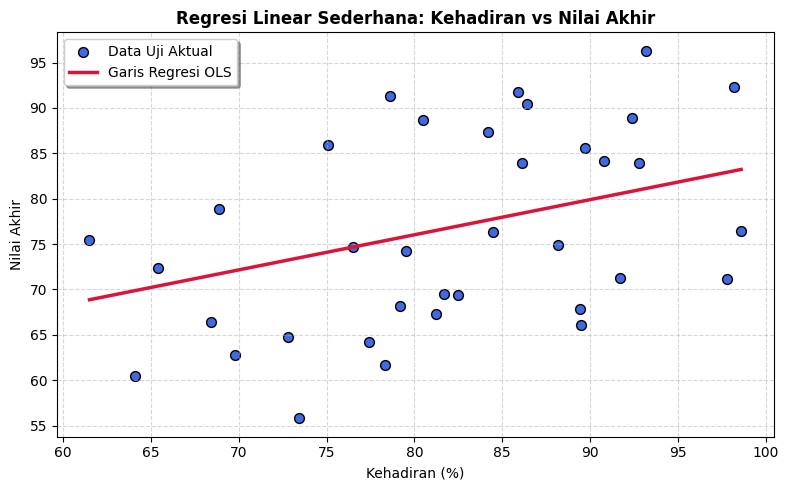

In [ ]:
absis = fitur_uji["kehadiran"]
garis_x = np.linspace(absis.min(), absis.max(), 100)
garis_y = beta0 + beta1 * garis_x

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(absis, target_uji, c="royalblue", edgecolors="black", s=50, label="Data Uji Aktual")
ax.plot(garis_x, garis_y, c="crimson", lw=2.5, label="Garis Regresi OLS")
ax.set_title("Regresi Linear Sederhana: Kehadiran vs Nilai Akhir", fontsize=12, fontweight="bold")
ax.set_xlabel("Kehadiran (%)")
ax.set_ylabel("Nilai Akhir")
ax.grid(True, ls="--", alpha=0.5)
ax.legend(frameon=True, shadow=True)
fig.tight_layout()
plt.show()

In [ ]:
reg_berganda = LinearRegression().fit(fitur_latih, target_latih)
prediksi_berganda = reg_berganda.predict(fitur_uji)

tabel_koefisien = (
    pd.DataFrame({"Atribut Prediktor": fitur.columns,
                  "Koefisien (Slope)": reg_berganda.coef_})
    .sort_values("Koefisien (Slope)", ascending=False)
    .reset_index(drop=True)
)

print("=== PARAMETER REGRESI LINEAR BERGANDA ===")
print(f"Intersep (beta_0) : {reg_berganda.intercept_:.4f}\n")
print("Tabel Koefisien Kemiringan (Slope):")
tabel_koefisien

=== PARAMETER REGRESI LINEAR BERGANDA ===
Intersep (beta_0) : 10.6180

Tabel Koefisien Kemiringan (Slope):


,Atribut Prediktor,Koefisien (Slope)
0,jam_belajar,1.743002
1,aktivitas_forum,0.582796
2,kehadiran,0.262629
3,nilai_tugas,0.166009
4,nilai_kuis,0.151344


In [ ]:
pengaruh_std = pd.Series(
    reg_berganda.coef_ * fitur_latih.std().values, index=fitur.columns, name="Pengaruh Terstandarisasi"
).sort_values(ascending=False).round(2)
pengaruh_std.to_frame()

,Pengaruh Terstandarisasi
jam_belajar,7.61
kehadiran,2.84
nilai_kuis,1.99
nilai_tugas,1.97
aktivitas_forum,1.54


In [ ]:
reg_knn = make_pipeline(
    StandardScaler(),
    KNeighborsRegressor(n_neighbors=5, metric="euclidean"),
)
reg_knn.fit(fitur_latih, target_latih)
prediksi_knn = reg_knn.predict(fitur_uji)

print("k-NN Regressor (k=5) selesai dilatih dengan fitur terstandarisasi.")

k-NN Regressor (k=5) selesai dilatih dengan fitur terstandarisasi.


In [ ]:
def evaluasi(aktual, prediksi):
    """Mengembalikan MAE, RMSE, dan R2."""
    return {
        "MAE": mean_absolute_error(aktual, prediksi),
        "RMSE": mean_squared_error(aktual, prediksi) ** 0.5,
        "R² Score": r2_score(aktual, prediksi),
    }

hasil = {
    "Regresi Linear Sederhana (Kehadiran)": evaluasi(target_uji, prediksi_sederhana),
    "Regresi Linear Berganda (5 Fitur)":    evaluasi(target_uji, prediksi_berganda),
    "k-NN Regressor (k=5)":                 evaluasi(target_uji, prediksi_knn),
}

tabel_evaluasi = pd.DataFrame(hasil).T.rename_axis("Model").reset_index().round(4)

print("=== TABEL RINGKASAN EVALUASI KINERJA (DATA UJI) ===")
tabel_evaluasi

=== TABEL RINGKASAN EVALUASI KINERJA (DATA UJI) ===


,Model,MAE,RMSE,R² Score
0,Regresi Linear Sederhana (Kehadiran),8.5613,9.5551,0.1890
1,Regresi Linear Berganda (5 Fitur),1.1193,1.4577,0.9811
2,k-NN Regressor (k=5),3.2450,3.9578,0.8609


In [ ]:
terbaik = tabel_evaluasi.loc[tabel_evaluasi["R² Score"].idxmax()]
print(f"Model terbaik: {terbaik['Model']}  (R² = {terbaik['R² Score']:.4f}, RMSE = {terbaik['RMSE']:.4f})")

Model terbaik: Regresi Linear Berganda (5 Fitur)  (R² = 0.9811, RMSE = 1.4577)
